# EXHEART 09 — Single-model baselines vs the stacked ensemble

**Reviewer question this closes:** "You build a four-model stack, but does it beat a single tuned model?" Without this table the architecture reads as overengineered.

**This notebook** evaluates each base learner *standalone* against the full calibrated stack on BRFSS 2015, on identical splits, reporting discrimination (AUC, AUPRC), calibration both raw and Platt-corrected (ECE, Brier), and operating-point sensitivity/specificity at pt = 0.12. It uses the committed base learners (the exact models inside the paper's stack), training only a plain logistic-regression baseline fresh.

**Honest framing to expect:** the MLP alone already reaches the stack's AUC (0.850). The defensible value of stacking is calibration stability and robustness across datasets, not raw discrimination. This table lets you make that argument with evidence, or concede it cleanly. Outputs to `results/brfss2015/baselines/`.

### 1. Determinism

In [1]:
import os
os.environ['PYTHONHASHSEED']='42'; os.environ['TF_DETERMINISTIC_OPS']='1'
import random, numpy as np
SEED=42; random.seed(SEED); np.random.seed(SEED)

### 2. Mount, git identity, paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import sys, json, shutil, joblib, warnings
import pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
DRIVE_ROOT='/content/drive/MyDrive/EXHEART_Research'; REPO_DIR=os.path.join(DRIVE_ROOT,'exheart-research')
for fn in ['.git-credentials','.gitconfig']:
    s=os.path.join(DRIVE_ROOT,fn)
    if os.path.exists(s): shutil.copy(s, os.path.join('/root',fn)); print('restored',fn)
DATA_2015=os.path.join(REPO_DIR,'data/brfss2015/heart_disease_health_indicators_BRFSS2015.csv')
MODELS=os.path.join(REPO_DIR,'models/brfss2015')
RESULTS=os.path.join(REPO_DIR,'results/brfss2015/baselines')
os.makedirs(RESULTS+'/figures',exist_ok=True); os.makedirs(RESULTS+'/tables',exist_ok=True)
print('Paths ready.')

Mounted at /content/drive
Paths ready.


### 3. Libraries + metric helpers

In [3]:
!pip install -q scikit-learn xgboost lightgbm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix)
from tensorflow import keras
PT=0.12
def ece(y,p,n=10):
    b=np.linspace(0,1,n+1); e=0.0
    for i in range(n):
        m=(p>=b[i])&(p<b[i+1])
        if m.sum(): e+=m.sum()*abs(y[m].mean()-p[m].mean())
    return e/len(y)
def metrics(y,p,pt=PT):
    yp=(p>=pt).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp).ravel()
    return dict(AUC=round(roc_auc_score(y,p),4), AUPRC=round(average_precision_score(y,p),4),
               Brier=round(brier_score_loss(y,p),4), ECE=round(ece(y,p),4),
               Sensitivity=round(tp/(tp+fn),4), Specificity=round(tn/(tn+fp),4))

### 4. Load data, reconstruct the paper split, load frozen base learners

In [4]:
df=pd.read_csv(DATA_2015); TGT='HeartDiseaseorAttack'
FEATURES=[c for c in df.columns if c!=TGT]
X=df[FEATURES].values; y=df[TGT].astype(int).values
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=SEED,stratify=y)
# calibration holdout carved from TRAIN (same convention as the stack's Platt fit)
Xtr2,Xcal,ytr2,ycal=train_test_split(Xtr,ytr,test_size=0.25,random_state=SEED,stratify=ytr)

xgb=joblib.load(os.path.join(MODELS,'xgb.pkl'))
lgbm=joblib.load(os.path.join(MODELS,'lgbm.pkl'))
rf=joblib.load(os.path.join(MODELS,'rf.pkl'))
meta=joblib.load(os.path.join(MODELS,'meta_lr.pkl'))
scaler=joblib.load(os.path.join(MODELS,'scaler.pkl'))
mlp=keras.models.load_model(os.path.join(MODELS,'mlp_full.keras'))
print('Frozen base learners + meta loaded. Test:', Xte.shape)

Frozen base learners + meta loaded. Test: (50736, 21)


### 5. Raw probability functions for every model + the stack

In [5]:
def p_xgb(A):  return xgb.predict_proba(A)[:,1]
def p_lgbm(A): return lgbm.predict_proba(A)[:,1]
def p_rf(A):   return rf.predict_proba(A)[:,1]
def p_mlp(A):  return mlp.predict(scaler.transform(A), verbose=0).ravel()
def p_stack(A):
    cols=np.column_stack([p_xgb(A),p_lgbm(A),p_rf(A),p_mlp(A)])
    return meta.predict_proba(cols)[:,1]
# plain logistic-regression baseline, trained fresh on standardized features
from sklearn.preprocessing import StandardScaler
lr_sc=StandardScaler().fit(Xtr)
logreg=LogisticRegression(max_iter=1000, class_weight='balanced').fit(lr_sc.transform(Xtr), ytr)
def p_logreg(A): return logreg.predict_proba(lr_sc.transform(A))[:,1]

MODELS_D={'LogReg':p_logreg,'XGBoost':p_xgb,'LightGBM':p_lgbm,'RandomForest':p_rf,'MLP':p_mlp,'Stack (EXHEART)':p_stack}

### 6. Evaluate each model raw and Platt-calibrated (calibration carved from train)

In [6]:
rows=[]
for name,fn in MODELS_D.items():
    raw_te=fn(Xte)
    m_raw=metrics(yte, raw_te)
    # Platt: fit LR on model's calibration-holdout probs, apply to test
    platt=LogisticRegression(max_iter=1000).fit(fn(Xcal).reshape(-1,1), ycal)
    cal_te=platt.predict_proba(raw_te.reshape(-1,1))[:,1]
    m_cal=metrics(yte, cal_te)
    rows.append({'model':name,'AUC':m_raw['AUC'],'AUPRC':m_raw['AUPRC'],
                 'ECE_raw':m_raw['ECE'],'ECE_platt':m_cal['ECE'],
                 'Brier_platt':m_cal['Brier'],
                 'Sensitivity_platt':m_cal['Sensitivity'],'Specificity_platt':m_cal['Specificity']})
    print(f"{name:16s} AUC {m_raw['AUC']:.4f} | ECE raw {m_raw['ECE']:.4f} -> platt {m_cal['ECE']:.4f} | sens {m_cal['Sensitivity']:.4f}")
tab=pd.DataFrame(rows)
tab.to_csv(RESULTS+'/tables/baselines.csv', index=False)
with open(RESULTS+'/tables/baselines.json','w') as f: json.dump(rows,f,indent=2)

LogReg           AUC 0.8470 | ECE raw 0.2558 -> platt 0.0056 | sens 0.7376
XGBoost          AUC 0.8488 | ECE raw 0.2409 -> platt 0.0120 | sens 0.7464
LightGBM         AUC 0.8501 | ECE raw 0.2448 -> platt 0.0094 | sens 0.7556
RandomForest     AUC 0.8459 | ECE raw 0.2553 -> platt 0.0095 | sens 0.7345
MLP              AUC 0.8493 | ECE raw 0.2585 -> platt 0.0070 | sens 0.7826
Stack (EXHEART)  AUC 0.8502 | ECE raw 0.2563 -> platt 0.0123 | sens 0.7721


### 7. Figure + read-out

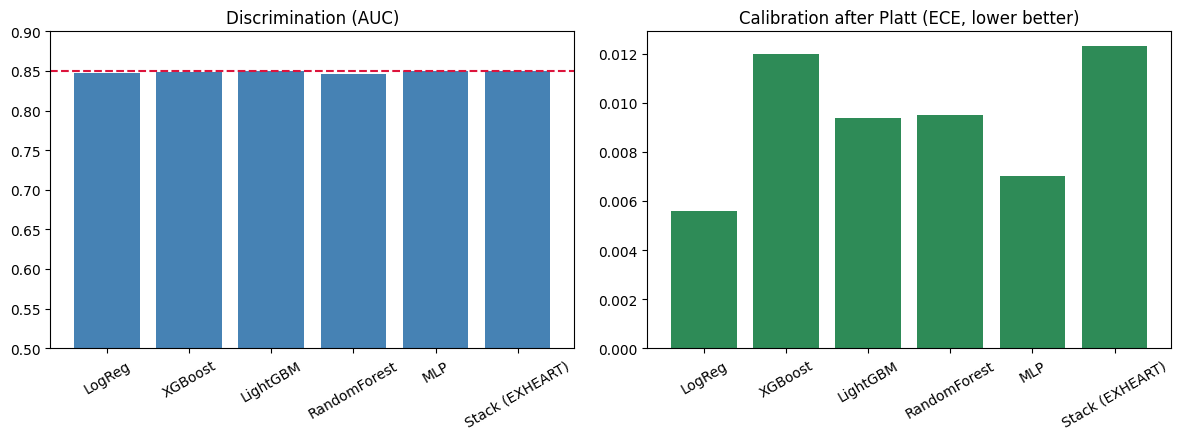

BASELINE COMPARISON
          model    AUC  AUPRC  ECE_raw  ECE_platt  Brier_platt  Sensitivity_platt  Specificity_platt
         LogReg 0.8470 0.3629   0.2558     0.0056       0.0706             0.7376             0.7949
        XGBoost 0.8488 0.3690   0.2409     0.0120       0.0704             0.7464             0.7872
       LightGBM 0.8501 0.3719   0.2448     0.0094       0.0702             0.7556             0.7818
   RandomForest 0.8459 0.3597   0.2553     0.0095       0.0709             0.7345             0.7918
            MLP 0.8493 0.3671   0.2585     0.0070       0.0703             0.7826             0.7619
Stack (EXHEART) 0.8502 0.3699   0.2563     0.0123       0.0706             0.7721             0.7717
------------------------------------------------------------
Best single model: LightGBM (AUC 0.8501)
Stack AUC 0.8502 | Stack ECE(platt) 0.0123 vs best-single ECE 0.0094
READ: stack ~ best single on AUC; justify the stack on calibration/robustness, not discrimination.


In [7]:
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
ax[0].bar(tab['model'], tab['AUC'], color='steelblue'); ax[0].set_ylim(0.5,0.9)
ax[0].set_title('Discrimination (AUC)'); ax[0].tick_params(axis='x',rotation=30)
ax[0].axhline(tab.loc[tab.model=='Stack (EXHEART)','AUC'].values[0],ls='--',c='crimson')
ax[1].bar(tab['model'], tab['ECE_platt'], color='seagreen')
ax[1].set_title('Calibration after Platt (ECE, lower better)'); ax[1].tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.savefig(RESULTS+'/figures/fig_baselines.png',dpi=150,bbox_inches='tight'); plt.show()

stack=tab[tab.model=='Stack (EXHEART)'].iloc[0]
best_single=tab[tab.model!='Stack (EXHEART)'].sort_values('AUC',ascending=False).iloc[0]
print('='*60); print('BASELINE COMPARISON')
print('='*60)
print(tab.to_string(index=False))
print('-'*60)
print(f"Best single model: {best_single['model']} (AUC {best_single['AUC']})")
print(f"Stack AUC {stack['AUC']} | Stack ECE(platt) {stack['ECE_platt']} vs best-single ECE {best_single['ECE_platt']}")
if stack['AUC']>=best_single['AUC'] and stack['ECE_platt']<=best_single['ECE_platt']:
    print("READ: stack dominates on both discrimination and calibration.")
elif abs(stack['AUC']-best_single['AUC'])<0.005:
    print("READ: stack ~ best single on AUC; justify the stack on calibration/robustness, not discrimination.")
else:
    print("READ: inspect the trade-off; report honestly.")
print('='*60)

### 8. Commit

In [8]:
%cd {REPO_DIR}
!git add results/brfss2015/baselines
!git commit -m "Add single-model baselines vs stacked ensemble (architecture justification)"
!git push origin main

/content/drive/MyDrive/EXHEART_Research/exheart-research
[main 5a1abda] Add single-model baselines vs stacked ensemble (architecture justification)
 3 files changed, 69 insertions(+)
 create mode 100644 results/brfss2015/baselines/figures/fig_baselines.png
 create mode 100644 results/brfss2015/baselines/tables/baselines.csv
 create mode 100644 results/brfss2015/baselines/tables/baselines.json
remote: Invalid username or token. Password authentication is not supported for Git operations.
fatal: Authentication failed for 'https://github.com/anasbiswas1/exheart-research.git/'
